# 05 — Frozen-model distribution-shift robustness
Fit each model once on the common unshifted development sample, then evaluate the same fitted parameters across a paired severity curve. The current DGP stress jointly increases innovation scale and common correlation; isolated shift mechanisms belong in the later confirmatory study.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.experiments.stress import ShiftConfig, run_shift_curve
OUT = ROOT / 'results' / 'shift'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
SEVERITIES = [0.0, 0.25, 0.5, 0.75, 1.0]
curve = run_shift_curve(
    SEVERITIES,
    config=ShiftConfig(seed=505),
    training_config=TrainingConfig(epochs=120, patience=15, seed=505),
    lambda_cal=100.0,
    sequential_weight=2000.0,
)
display(curve)
curve.to_csv(OUT / 'frozen_shift_curve.csv', index=False)

,severity,model,model_index,lambda_cal,lambda_seq,nll,rmse,energy_score,coverage,interval_width,...,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks,delta_nll,delta_energy_score,delta_interval_score,delta_pit_calibration_error,delta_pit_mean_absolute_autocorrelation
0,0.00,RNN,0,0.0,0.0,5.221779,0.913593,1.209362,0.921591,3.250464,...,0.077923,0.065179,0.001054,0.082002,0.066349,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.00,BRNN,1,0.0,0.0,5.358898,0.926197,1.228357,0.925000,3.362199,...,0.072858,0.068096,0.001215,0.077741,0.073462,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.00,CA-RNN,2,100.0,0.0,5.232678,0.915227,1.210668,0.928409,3.264383,...,0.080919,0.065871,0.001141,0.084047,0.066372,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.00,CA-BRNN,3,100.0,0.0,5.405815,0.936079,1.238622,0.917045,3.296147,...,0.076621,0.062096,0.000999,0.083797,0.067853,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.00,CA-RNN sequential,4,100.0,2000.0,5.247562,0.915026,1.212360,0.935227,3.396602,...,0.081173,0.071429,0.001569,0.082618,0.073832,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.00,CA-BRNN sequential,5,100.0,2000.0,5.424377,0.928269,1.231483,0.917045,3.375186,...,0.067156,0.065514,0.001270,0.073760,0.067864,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.25,RNN,0,0.0,0.0,6.031520,1.133642,1.492969,0.844318,3.250987,...,0.077195,0.069413,0.001414,0.078627,0.076862,0.809741,0.283608,0.986909,0.000097,-0.000728
7,0.25,BRNN,1,0.0,0.0,6.184600,1.147800,1.510153,0.867045,3.429950,...,0.070618,0.067510,0.001240,0.072194,0.069661,0.825703,0.281796,0.909199,0.000047,-0.002240
8,0.25,CA-RNN,2,100.0,0.0,6.040558,1.135866,1.494020,0.839773,3.263500,...,0.080871,0.067298,0.001412,0.081159,0.072428,0.807880,0.283352,0.986247,0.000029,-0.000047
9,0.25,CA-BRNN,3,100.0,0.0,6.269751,1.159140,1.524858,0.859091,3.380606,...,0.073791,0.067954,0.001367,0.077492,0.067299,0.863936,0.286236,0.984924,0.000411,-0.002830


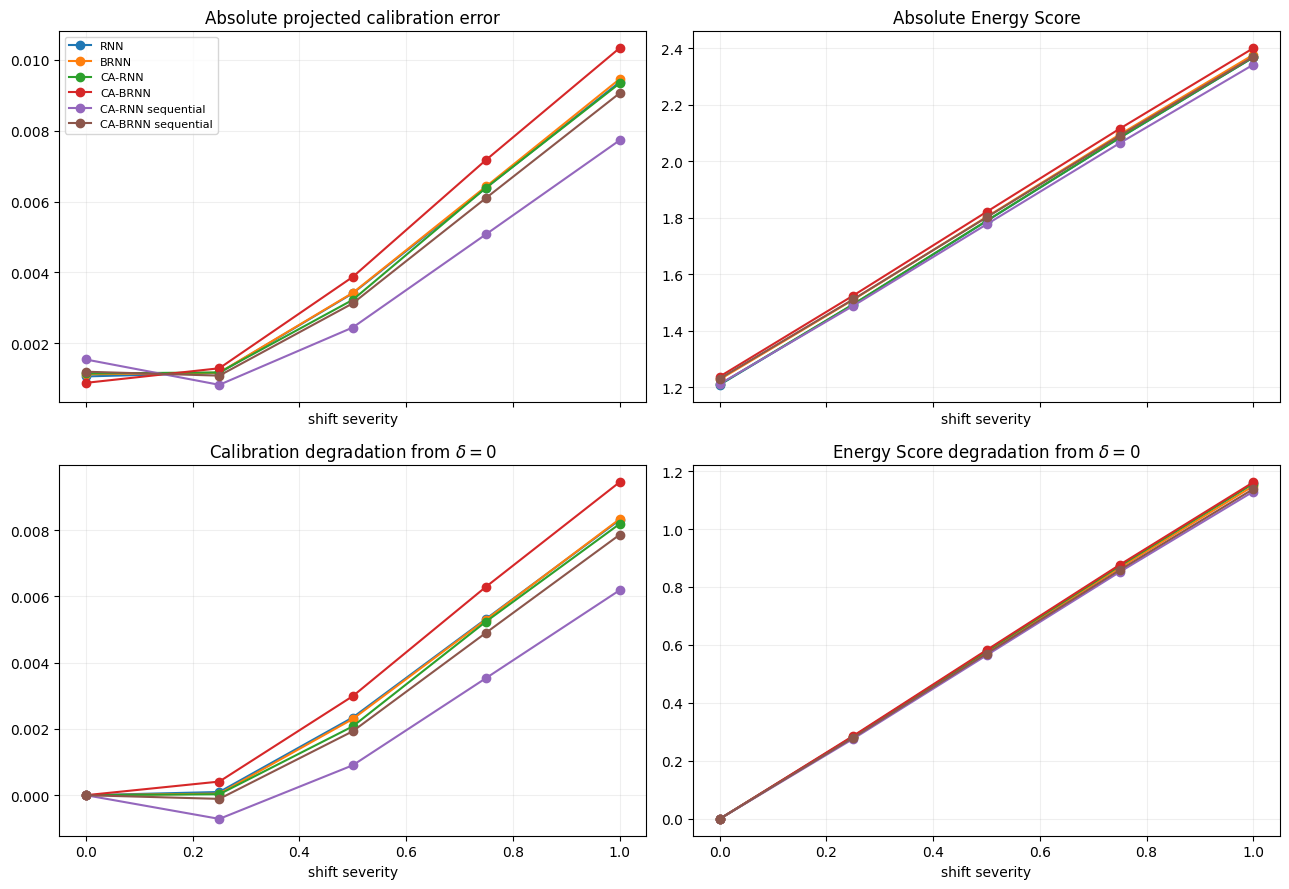

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for model, group in curve.groupby('model', sort=False):
    group = group.sort_values('severity')
    axes[0, 0].plot(group.severity, group.pit_calibration_error, marker='o', label=model)
    axes[0, 1].plot(group.severity, group.energy_score, marker='o', label=model)
    axes[1, 0].plot(group.severity, group.delta_pit_calibration_error, marker='o', label=model)
    axes[1, 1].plot(group.severity, group.delta_energy_score, marker='o', label=model)
axes[0, 0].set_title('Absolute projected calibration error')
axes[0, 1].set_title('Absolute Energy Score')
axes[1, 0].set_title(r'Calibration degradation from $\delta=0$')
axes[1, 1].set_title(r'Energy Score degradation from $\delta=0$')
for axis in axes.flat:
    axis.set_xlabel('shift severity')
    axis.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()

In [4]:
terminal = curve.loc[curve.severity.eq(max(SEVERITIES))].copy()
display(terminal[[
    'model', 'nll', 'energy_score', 'pit_calibration_error',
    'pit_mean_absolute_autocorrelation', 'delta_energy_score',
    'delta_pit_calibration_error'
]].sort_values('pit_calibration_error'))

,model,nll,energy_score,pit_calibration_error,pit_mean_absolute_autocorrelation,delta_energy_score,delta_pit_calibration_error
28,CA-RNN sequential,8.133904,2.341621,0.007728,0.081308,1.129261,0.006183
29,CA-BRNN sequential,8.502097,2.369509,0.009057,0.069611,1.138027,0.007856
26,CA-RNN,8.387515,2.367463,0.009334,0.079420,1.156795,0.008183
24,RNN,8.327542,2.367084,0.009370,0.076242,1.157723,0.008302
25,BRNN,8.477262,2.376587,0.009455,0.073877,1.148230,0.008328
27,CA-BRNN,8.629349,2.399941,0.010330,0.074843,1.161319,0.009443


## Interpretation rules
Report both absolute performance and degradation from severity zero. A model is not robust merely because it starts from worse nominal performance and therefore deteriorates less. Treat this notebook as developmental: the combined scale/dependence stress, one DGP seed, and provisional regularization weights do not support confirmatory conclusions.